## Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6) # set default figure size for plots to 10x6
plt.rcParams["figure.dpi"] = 100 # set default DPI (dots per inch) for plots to 100

# enable inline plotting in Jupyter notebooks
%matplotlib inline 

## Load Dataset

In [6]:
df = pd.read_csv('../data/train.csv')

df.shape

(891, 12)

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Key observations:**
- The dataset has 891 rows and 12 columns.
- Survived is the target variable:
    - 0 did not survived.
    - survived.

## Dataset Overview

In [8]:
df.info() # data types and missing values

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


**Key observations:**
- Three columns have missing values:
    - Age 714/891.
    - Cabin 204/891.
    - Embarked 889/891.

In [9]:
df.describe() # summary statistics of numerical columns

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Key observations:**
- Only 38.4% of passengers **survived** (mean of Survived ≈ 0.384), a moderately imbalanced dataset.
- **Age:** average ~29.7 years, ranging from 0.42 to 80, so both infants and elderly passengers are present.
- **Fare:** strongly right-skewed distribution (mean 32.2 vs. median 14.45, max 512.3) — suggests outliers and a long tail, likely driven by wealthy 1st-class passengers. The highest values pull the mean towards a higher value, almost twice the median.
- **Pclass:** median is 3, meaning most passengers traveled in 3rd class.
- **SibSp and Parch** (family members aboard): most passengers traveled alone or with very few relatives (median 0 for both).

In [10]:
df.describe(include='object') # summary statistics for categorical variables

C:\Users\maria\AppData\Local\Temp\ipykernel_6504\1937519667.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object') # summary statistics for categorical variables


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


**Key observations:**
- **Name and Ticket** are almost entirely unique values (Ticket has 681 unique out of 891) — not directly useful as categorical features as-is, though Name could be mined for "titles" (Mr., Mrs., Miss, etc.).
- **Sex:** male-dominated (577/891 males).
- **Embarked:** most common port is "S" (Southampton), with 644 of the 889 filled records.
- **Cabin:** 147 unique values out of only 204 filled — very sparse, hard to use directly without grouping (e.g., extracting just the deck letter).

## Missing Values Analysis

In [11]:
df.isnull().sum() # count of missing values per column

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
(df.isnull().sum() / len(df) * 100).round(2) # percentage of missing values per column

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

In [13]:
missing = pd.DataFrame({
    "Missing count": df.isnull().sum(),
    "Missing percentage": (df.isnull().sum() / len(df) * 100).round(2)
}) # count and percentage of missing values per column

In [14]:
missing = missing[missing["Missing count"] > 0].sort_values(by="Missing count", ascending=False)
missing

,Missing count,Missing percentage
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


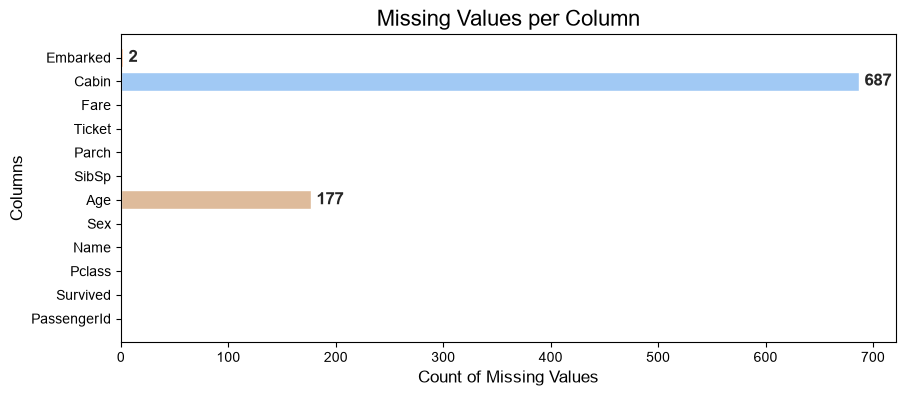

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))

# set the style
sns.set_theme(style="whitegrid") # set the general style to whitegrid
colors = sns.color_palette("pastel")

# horizontal bar chart
ax.barh(df.columns, df.isnull().sum(), color=colors)

# title
ax.set_title("Missing Values per Column", fontsize=16)

# x and y labels
ax.set_xlabel("Count of Missing Values", fontsize=12)
ax.set_ylabel("Columns", fontsize=12)

# print number of missing values
for i, v in enumerate(df.isnull().sum()):
    if v > 0: ax.text(v + 5, i, str(v), va="center", fontweight="bold")


**Key observations:**
- **Cabin** has 77.1% missing. Given the volume, it's usually best to drop the column or turn it into a binary flag ("has a recorded cabin or not"). Likely drop it.
- **Age** has 19.87% missing. A manageable proportion, a good candidate for imputation (impute using group medians).
- **Embarked** has only 0.22% (2 values) missing. Drop those 2 rows or impute with the mode ("S"). Easy to fill with the mode.

## Target Variable Analysis

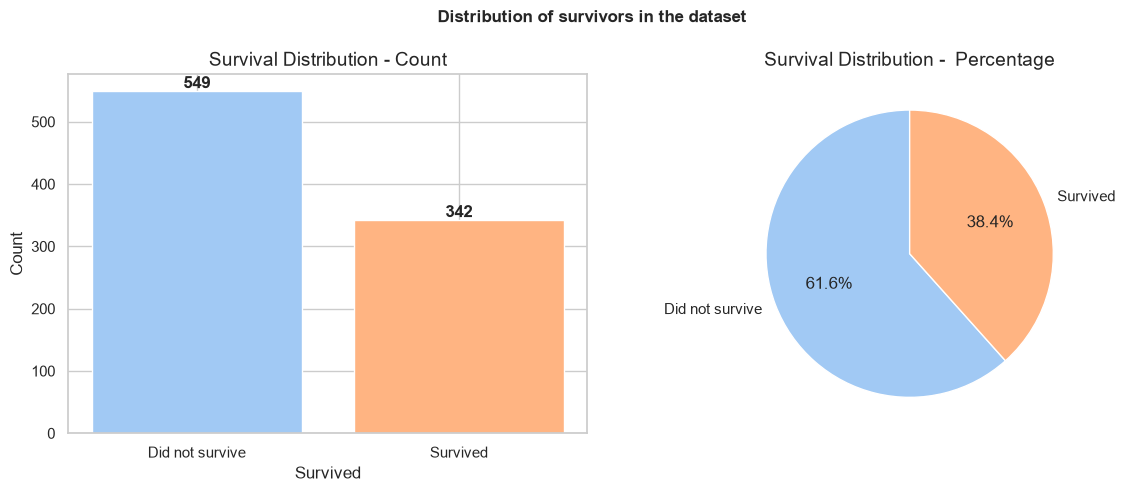

Survival Distribution:
38.38 %


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # create a figure with 1 row and 2 columns of subplots

survived = df['Survived'].value_counts() # count of survivors 

# bar chart for survival distribution
axes[0].bar(["Did not survive", "Survived"], survived.values, color=colors)
axes[0].set_title('Survival Distribution - Count', fontsize=14)
axes[0].set_xlabel('Survived', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# add the count of survivors on top of the bars
for i, v in enumerate(survived.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')


# pie chart for survival distribution

axes[1].pie(survived.values, labels=["Did not survive", "Survived"], autopct='%1.1f%%', startangle=90, colors=colors)
axes[1].set_title('Survival Distribution -  Percentage', fontsize=14)

plt.suptitle('Distribution of survivors in the dataset', fontsize=12, fontweight='bold')
plt.tight_layout() # adjust subplots to fit into figure area
plt.show() # display the plots

print("Survival Distribution:")
print(round(df['Survived'].mean() * 100, 2), "%")

**Survival Distribution:** Only 38.38% of passengers survived, while 61.62% did not, indicating an imbalanced target variable with a higher proportion of non-survivors

## Univariate Analysis - Numerical Features

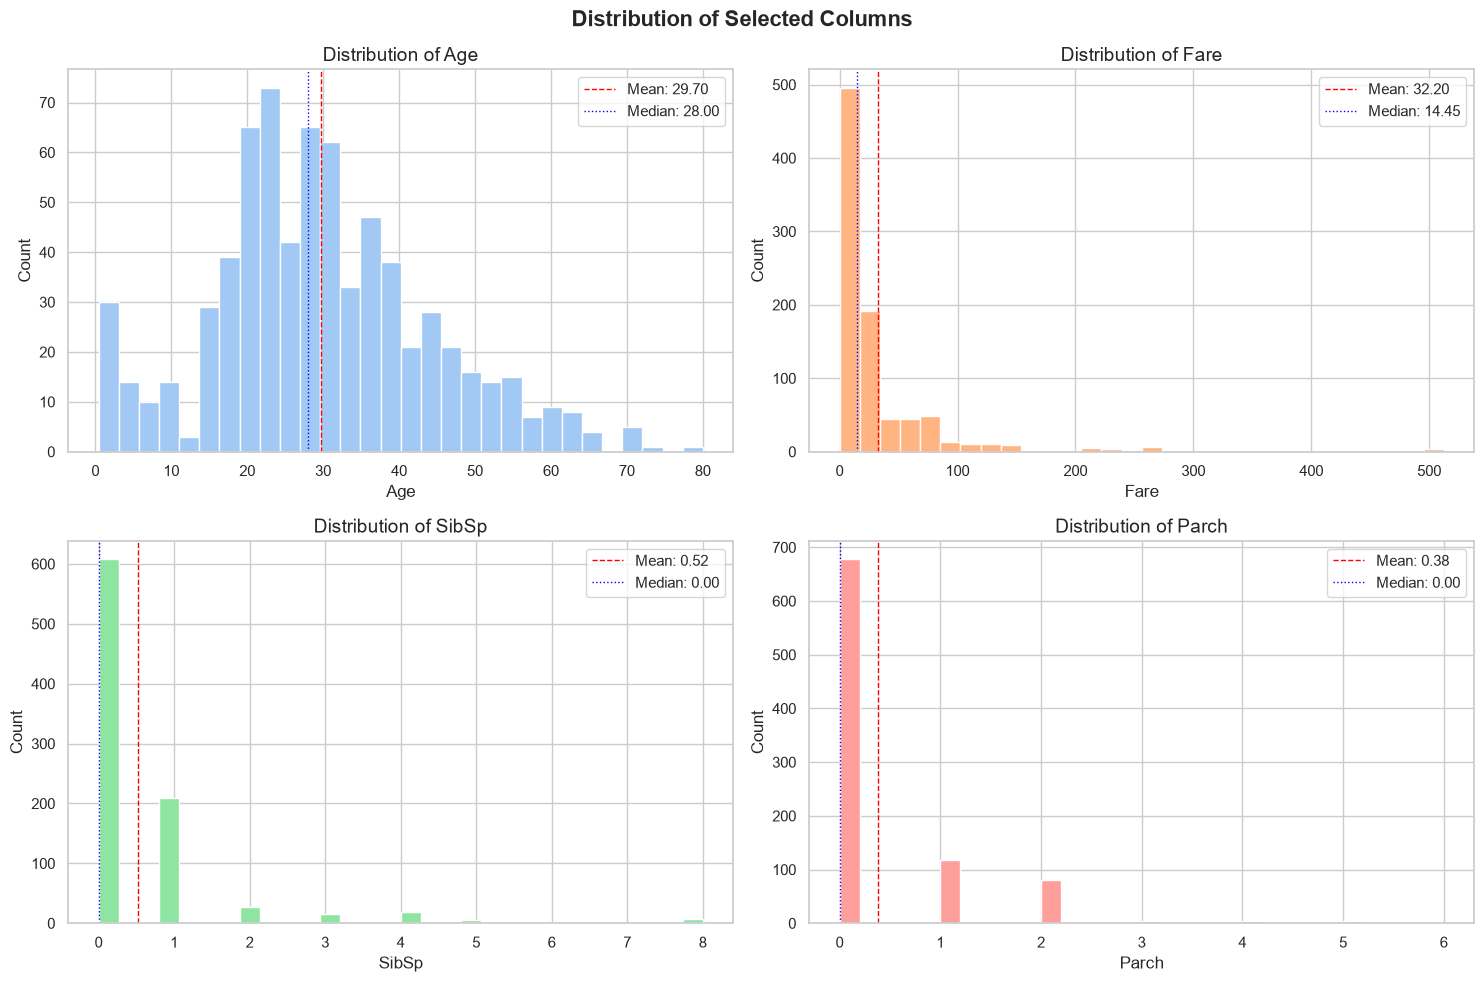

In [17]:
cols = ['Age', 'Fare', 'SibSp', 'Parch'] # columns to analyze

fig, axes = plt.subplots(2, 2, figsize=(15, 10)) # create a figure with 2 rows and 2 columns of subplots
axes = axes.flatten() # flatten the 2D array of axes to 1D for easier iteration

for i, col in enumerate(cols):
    axes[i].hist(df[col].dropna(), bins=30, color=colors[i], edgecolor='white') # histogram for each column
    axes[i].set_title(f'Distribution of {col}', fontsize=14) # set title for each subplot
    axes[i].set_xlabel(col, fontsize=12) # set x-axis label for each subplot
    axes[i].set_ylabel('Count', fontsize=12) # set y-axis label for each subplot

    # add vertical lines for mean and median (makes sense for numerical data)
    axes[i].axvline(df[col].mean(), color="red", linestyle='dashed', linewidth=1, label=f'Mean: {df[col].mean():.2f}') # add a vertical line for the mean
    axes[i].axvline(df[col].median(), color="blue", linestyle='dotted', linewidth=1, label=f'Median: {df[col].median():.2f}') # add a vertical line for the median
    axes[i].legend()

plt.suptitle('Distribution of Selected Columns', fontsize=16, fontweight='bold') # set a super title for the figure
plt.tight_layout() # adjust subplots to fit into figure area
plt.show() # display the plots

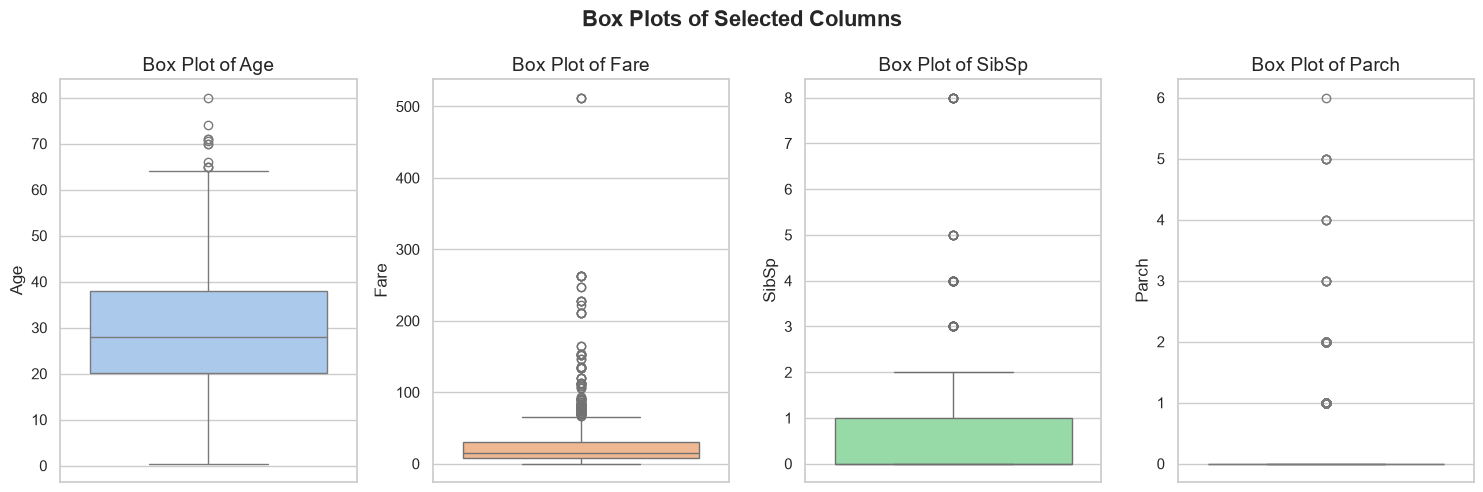

In [18]:
# box plots for the same columns to visualize outlier (one line only)
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i], color=colors[i]) # box plot for each column
    axes[i].set_title(f'Box Plot of {col}', fontsize=14) # set title for each subplot
    axes[i].set_ylabel(col, fontsize=12) # set y-axis label for each subplot

plt.suptitle('Box Plots of Selected Columns', fontsize=16, fontweight='bold') # set a super title for the figure
plt.tight_layout() # adjust subplots to fit into figure area   
plt.show() # display the plots

**Key observations:**
- **Ages**: almost normally distributed, centered around aproximately 30. Outliers at high ages.
- **Fare**: heavily right-skewed. Significant outliers with only a few passengers paying high fares.
- **SibSp and Parch**: also right-skewed. Most passenger traveled alone or with one or two members.

## Univariate Analysis - Categorical Features

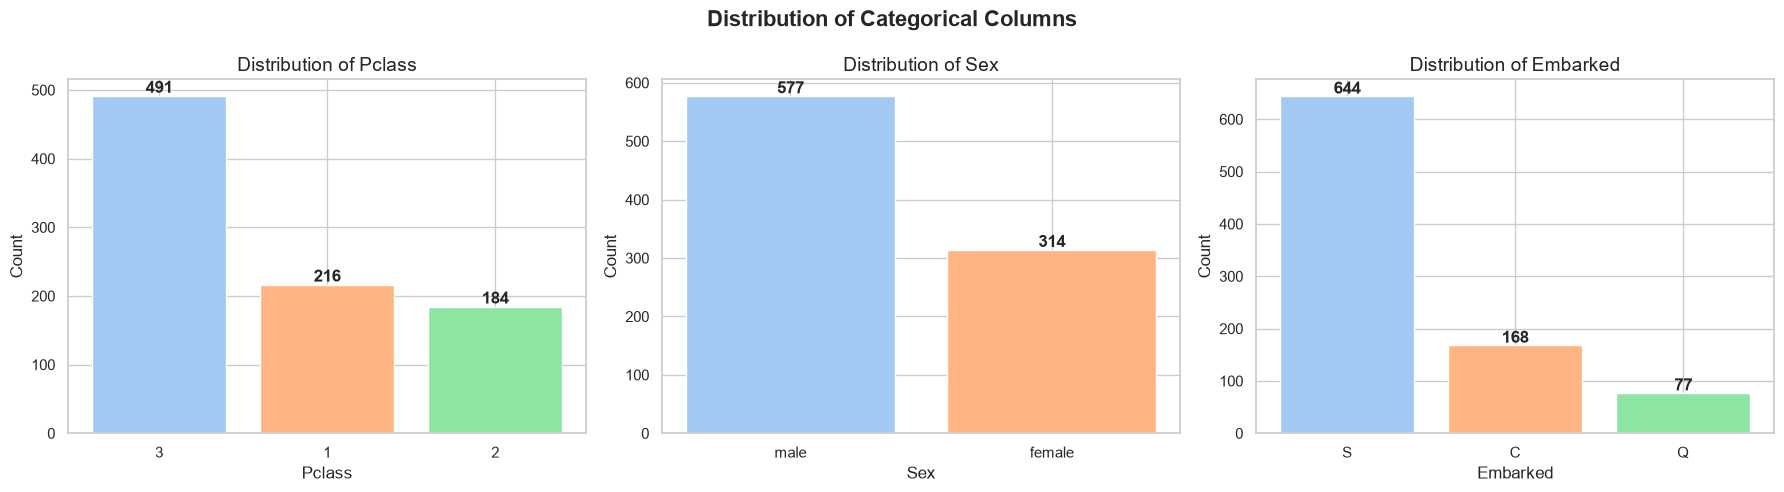

In [19]:
categorical_cols = ['Pclass', 'Sex', 'Embarked'] # categorical columns to analyze

fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # create a figure with 1 row and 3 columns of subplots

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts() # count of each category in the column
    axes[i].bar(counts.index.astype(str), counts.values, color=colors) # bar chart for each categorical column
    axes[i].set_title(f'Distribution of {col}', fontsize=14) # set title for each subplot
    axes[i].set_xlabel(col, fontsize=12) # set x-axis label for each subplot
    axes[i].set_ylabel('Count', fontsize=12) # set y-axis label for each subplot
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 5, str(v), ha='center', fontweight='bold') # add the count of each category on top of the bars

plt.suptitle('Distribution of Categorical Columns', fontsize=16, fontweight='bold') # set a super title for the figure
plt.tight_layout() # adjust subplots to fit into figure area
plt.show() # display the plots

**Key Observations:**
- **Pclass**: majority traveled in 3rd class.
- **Gender**: males are almost twice as many as females in the dataset.
- **Embarked**: most passengers boarded ate Southampton (S).

## Bivariate Analysis - Survival and Features

**Why analyze Sex, Pclass, and Embarked specifically vs Survived?**
- Sex has only 2 categories, easy to compare
- Pclass has a natural order (1st > 2nd > 3rd), so there's a suspected monotonic relationship with social status/survival
- Embarked indirectly correlates with Pclass (more 1st class passengers embarked at Cherbourg)

These three were the obvious candidates because they were already "clean" and had plausible historical hypotheses behind them (women and children first, the elite had priority on lifeboats).

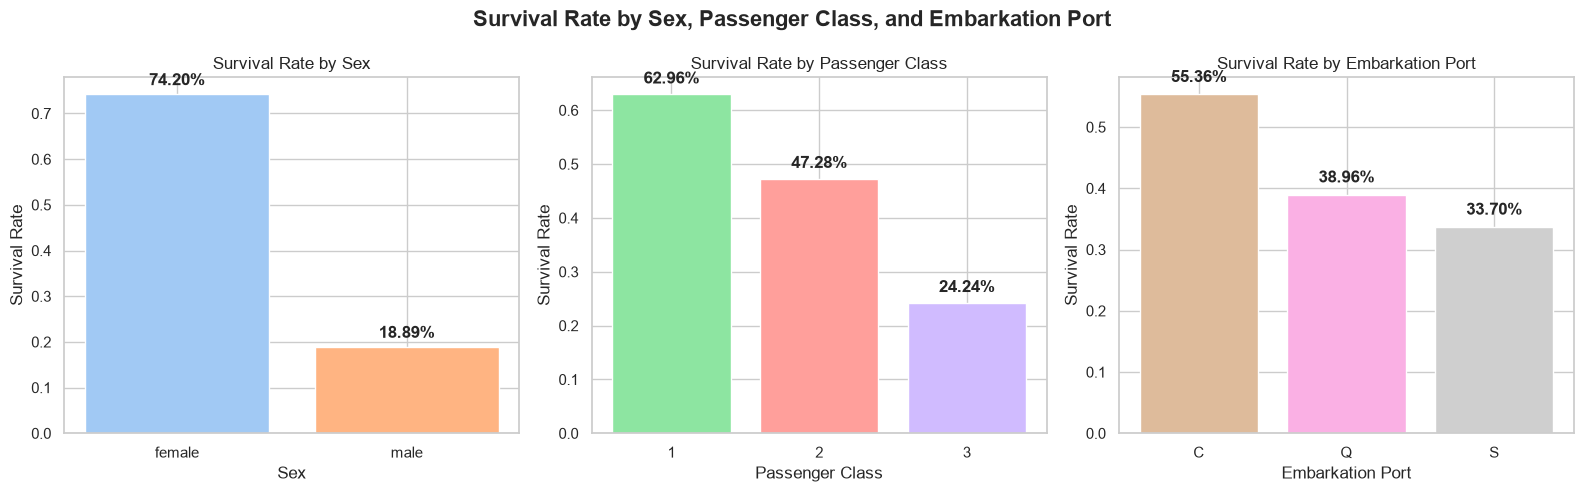

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Survival by sex
survival_by_sex = df.groupby("Sex") ["Survived"].mean() # calculate the mean survival rate for each sex because it is a binary variable (0 or 1), the mean gives the proportion of survivors in each group
axes[0].bar(survival_by_sex.index, survival_by_sex.values, color=colors[:2]) # bar chart for survival by sex
axes[0].set_title('Survival Rate by Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Survival Rate')
for i, v in enumerate(survival_by_sex.values):
    axes[0].text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold') # add the survival rate on top of the bars

# Survival by passenger class
survival_by_class = df.groupby("Pclass")["Survived"].mean() # calculate the mean survival rate for each passenger class
axes[1].bar(survival_by_class.index.astype(str), survival_by_class.values, color=colors[2:5]) # bar chart for survival by passenger class
axes[1].set_title('Survival Rate by Passenger Class')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Survival Rate')
for i, v in enumerate(survival_by_class.values):
    axes[1].text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold') # add the survival rate on top of the bars

# Survival by embarkation port
survival_by_embarked = df.groupby("Embarked")["Survived"].mean()
axes[2].bar(survival_by_embarked.index.astype(str), survival_by_embarked.values, color=colors[5:]) # bar chart for survival by embarkation port
axes[2].set_title('Survival Rate by Embarkation Port')
axes[2].set_xlabel('Embarkation Port')
axes[2].set_ylabel('Survival Rate')
for i, v in enumerate(survival_by_embarked.values):
    axes[2].text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold') # add the survival rate on top of the bars

plt.suptitle('Survival Rate by Sex, Passenger Class, and Embarkation Port', fontsize=16, fontweight='bold') # set a super title for the figure
plt.tight_layout() # adjust subplots to fit into figure area    
plt.show()


After seeing that Sex and Pclass individually matter a lot, the natural question is: are these effects independent, or do they combine? For example, does "being female" help equally in 1st and 3rd class, or did 3rd-class women have much worse luck than 1st-class women?

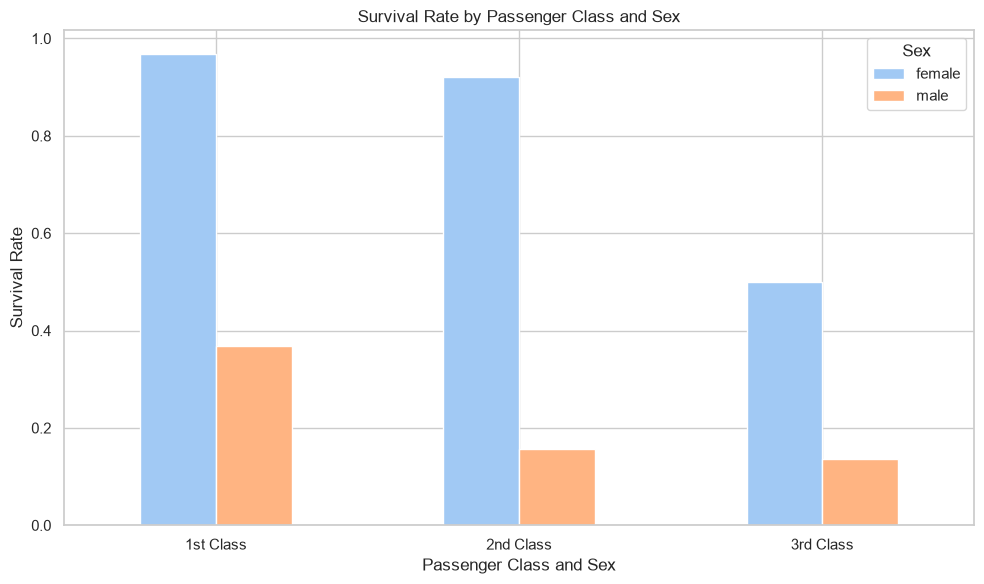

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

survival_grouped = df.groupby(["Pclass", "Sex"])["Survived"].mean().unstack() # group by passenger class and sex, then calculate the mean survival rate, and unstack to create a DataFrame suitable for plotting
survival_grouped.plot(kind="bar", ax=ax, color=colors[:2]) # plot the grouped survival rates as a bar chart
ax.set_xlabel("Passenger Class and Sex")
ax.set_ylabel("Survival Rate")
ax.set_title("Survival Rate by Passenger Class and Sex")
ax.set_xticklabels(["1st Class", "2nd Class", "3rd Class"], rotation=0) # set x-tick labels to passenger class and rotate them to 0 degrees
ax.legend(title="Sex")

plt.tight_layout() # adjust subplots to fit into figure area
plt.show() # display the plot

**Key Insights:**
- Women had a significantly higher survival rate than men, with approximately 74% of women surviving compared to only 19% of men (women and children first).
- 1st class passengers had the highest survival rate at around 63%, followed by 2nd class at 47%, and 3rd class at only 24%.
- Cherbourg passengers had a higher survival rate (55%) compared to those who embarked from Southampton (34%) and Queenstown (38%), probably due to their higher socioeconomic status. So its not as relevant to the survival rate as the other factors.

A proportion bar chart requires discrete categories. Age and Fare are continuous so if we tried *groupby("Age")["Survived"].mean()*, we'd get one bar for each exact age (e.g., 22.0, 22.5, 23.0...), which would be unreadable and noisy (few people per exact age = unstable averages).

So we are analysing Age and Fare with histograms/KDE/boxplot, instead of a proportion bar chart.

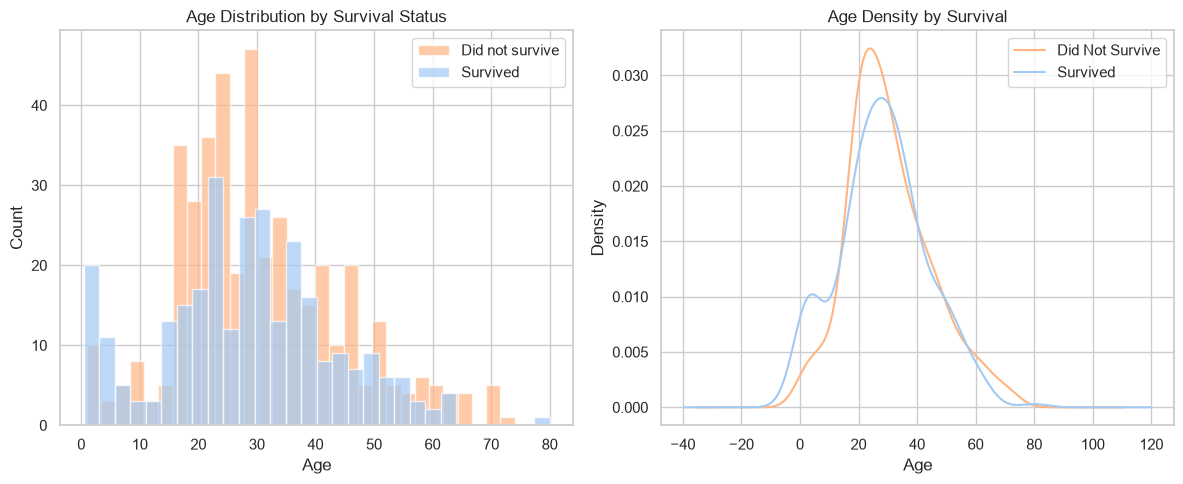

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Overlapping histograms for age distribution of survivors and non-survivors
axes[0].hist(df[df["Survived"] == 0]["Age"].dropna(), bins=30, color=colors[1], alpha=0.7, label="Did not survive", edgecolor='white') # histogram for age of non-survivors
axes[0].hist(df[df["Survived"] == 1]["Age"].dropna(), bins=30, color=colors[0], alpha=0.7, label="Survived", edgecolor='white') # histogram for age of survivors
axes[0].set_title("Age Distribution by Survival Status")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].legend()

# Overlapping histograms for fare distribution of survivors and non-survivors
df[df["Survived"] == 0]["Age"].dropna().plot.kde(ax=axes[1], color=colors[1], label="Did Not Survive")
df[df["Survived"] == 1]["Age"].dropna().plot.kde(ax=axes[1], color=colors[0], label="Survived")
axes[1].set_title("Age Density by Survival")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

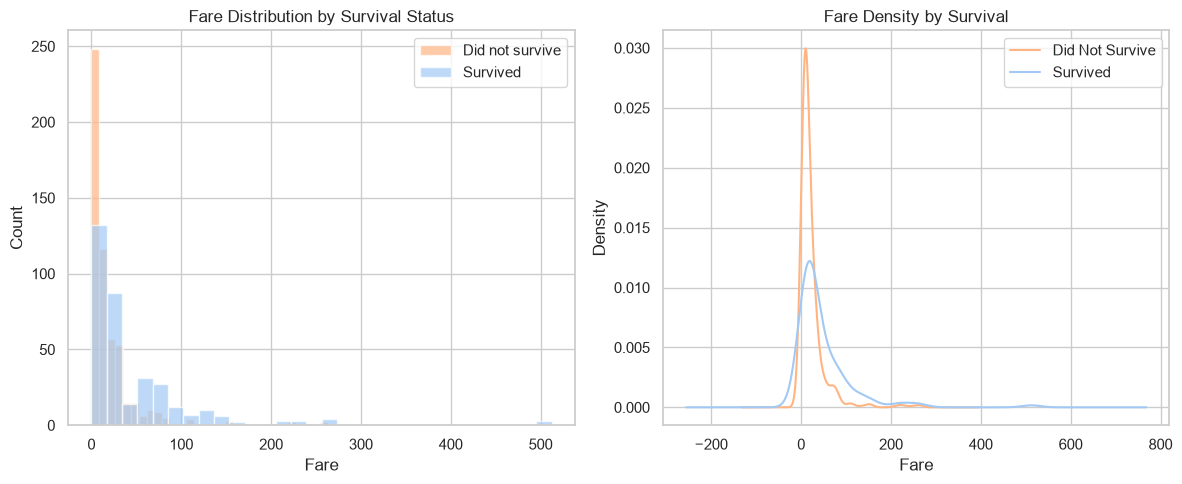

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Overlapping histograms for fare distribution of survivors and non-survivors
axes[0].hist(df[df["Survived"] == 0]["Fare"].dropna(), bins=30, color=colors[1], alpha=0.7, label="Did not survive", edgecolor='white') # histogram for fare of non-survivors
axes[0].hist(df[df["Survived"] == 1]["Fare"].dropna(), bins=30, color=colors[0], alpha=0.7, label="Survived", edgecolor='white') # histogram for fare of survivors
axes[0].set_title("Fare Distribution by Survival Status")
axes[0].set_xlabel("Fare")
axes[0].set_ylabel("Count")
axes[0].legend()

# Overlapping histograms for fare distribution of survivors and non-survivors
df[df["Survived"] == 0]["Fare"].dropna().plot.kde(ax=axes[1], color=colors[1], label="Did Not Survive")
df[df["Survived"] == 1]["Fare"].dropna().plot.kde(ax=axes[1], color=colors[0], label="Survived")
axes[1].set_title("Fare Density by Survival")
axes[1].set_xlabel("Fare")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

Too many outliers in the Fare distribution, especially for survivors. This is likely due to a few passengers who paid significantly higher fares, which skews the distribution. Lets investigate using a box plot to visualize the outliers in the Fare distribution.

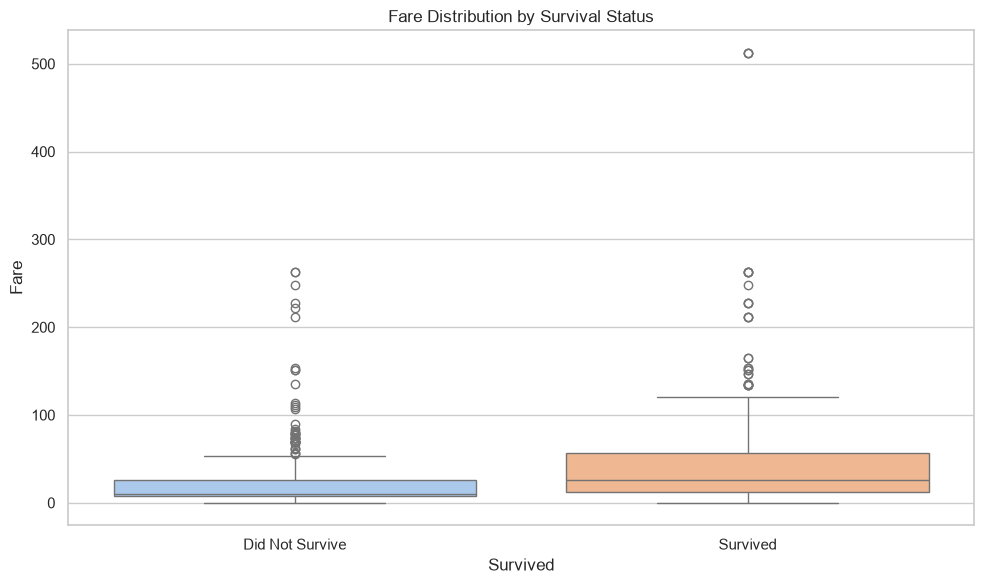

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(x="Survived", y="Fare", data=df, ax=ax, hue="Survived", palette=colors[:2], legend=False)
ax.set_xticks([0, 1]) # set x-ticks to 0 and 1 for the two survival categories
ax.set_xticklabels(["Did Not Survive", "Survived"])
ax.set_title("Fare Distribution by Survival Status")
ax.set_ylabel("Fare")
plt.tight_layout()
plt.show()

**Key Insights:**
- Children below the age of 10 had a higher survival rate compared to adults, indicating that children were prioritized during the evacuation process.
- Passengers who survived paid higher fares on average, suggesting that wealthier passengers had better access to lifeboats or were given priority during the evacuation. Which makes sense since higher fares were related with higher classes.

## Family Size

The hypothesis is: SibSp (siblings/spouses aboard) and Parch (parents/children aboard) alone are weak predictors because each one captures only part of the "family" concept. Someone could have Parch=0 but SibSp=3 (traveling with siblings, no parents/children), they're still "with family," not alone. Adding the two together (+1 for the person themselves) creates a more robust concept: "total family group size aboard."

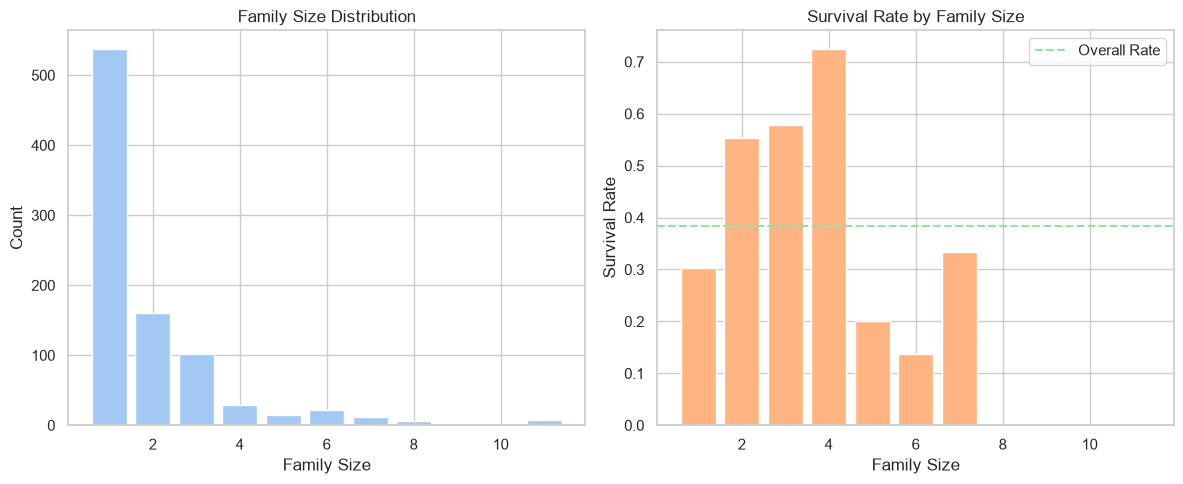

In [39]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1 # create a new column for family size by adding siblings/spouses and parents/children, plus 1 for the passenger themselves

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

family_counts = df["FamilySize"].value_counts().sort_index()
axes[0].bar(family_counts.index, family_counts.values, color=colors[0], edgecolor="white")
axes[0].set_title("Family Size Distribution")
axes[0].set_xlabel("Family Size")
axes[0].set_ylabel("Count")

# Survival rate by family size
survival_by_family = df.groupby("FamilySize")["Survived"].mean()
axes[1].bar(survival_by_family.index, survival_by_family.values, color=colors[1], edgecolor="white")
axes[1].set_title("Survival Rate by Family Size")
axes[1].set_xlabel("Family Size")
axes[1].set_ylabel("Survival Rate")
axes[1].axhline(y=df["Survived"].mean(), color=colors[2], linestyle="--", label="Overall Rate")
axes[1].legend()

plt.tight_layout()
plt.show()